<a href="https://colab.research.google.com/github/mdkamrulhasan/data_mining_kdd/blob/main/notebooks/Diabetes_EDA_Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LOADING LIBRARIES**

In [ ]:
#Loading libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# **DATA IMPORTATION**

In [ ]:
diabetes = pd.read_csv("https://raw.githubusercontent.com/mdkamrulhasan/data_mining_kdd/main/data/diabetes/diabetes_data.csv", encoding='unicode_escape')

# **EXPLORATORY DATA ANALYSIS(EDA)**

In [ ]:
#nspecting the first five rows of the dataset

diabetes.head()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
diabetes.info()

In [ ]:
#converting variables to correct datatypes

diabetes['Age'] = diabetes['Age'].astype(int)
diabetes['Sex'] = diabetes['Sex'].astype(int)
diabetes['HighChol'] = diabetes['HighChol'].astype(int)
diabetes['CholCheck'] = diabetes['CholCheck'].astype(int)
diabetes['Smoker'] = diabetes['Smoker'].astype(int)
diabetes['HeartDiseaseorAttack'] = diabetes['HeartDiseaseorAttack'].astype(int)
diabetes['PhysActivity'] = diabetes['PhysActivity'].astype(int)
diabetes['Fruits'] = diabetes['Fruits'].astype(int)
diabetes['Veggies'] = diabetes['Veggies'].astype(int)
diabetes['HvyAlcoholConsump'] = diabetes['HvyAlcoholConsump'].astype(int)
diabetes['GenHlth'] = diabetes['GenHlth'].astype(int)
diabetes['MentHlth'] = diabetes['MentHlth'].astype(int)
diabetes['PhysHlth'] = diabetes['PhysHlth'].astype(int)
diabetes['DiffWalk'] = diabetes['DiffWalk'].astype(int)
diabetes['Stroke'] = diabetes['Stroke'].astype(int)
diabetes['HighBP'] = diabetes['HighBP'].astype(int)
diabetes['Diabetes'] = diabetes['Diabetes'].astype(int)


# **FEATURE ENGINEERING**

# **CORRELATION ANALYSIS**

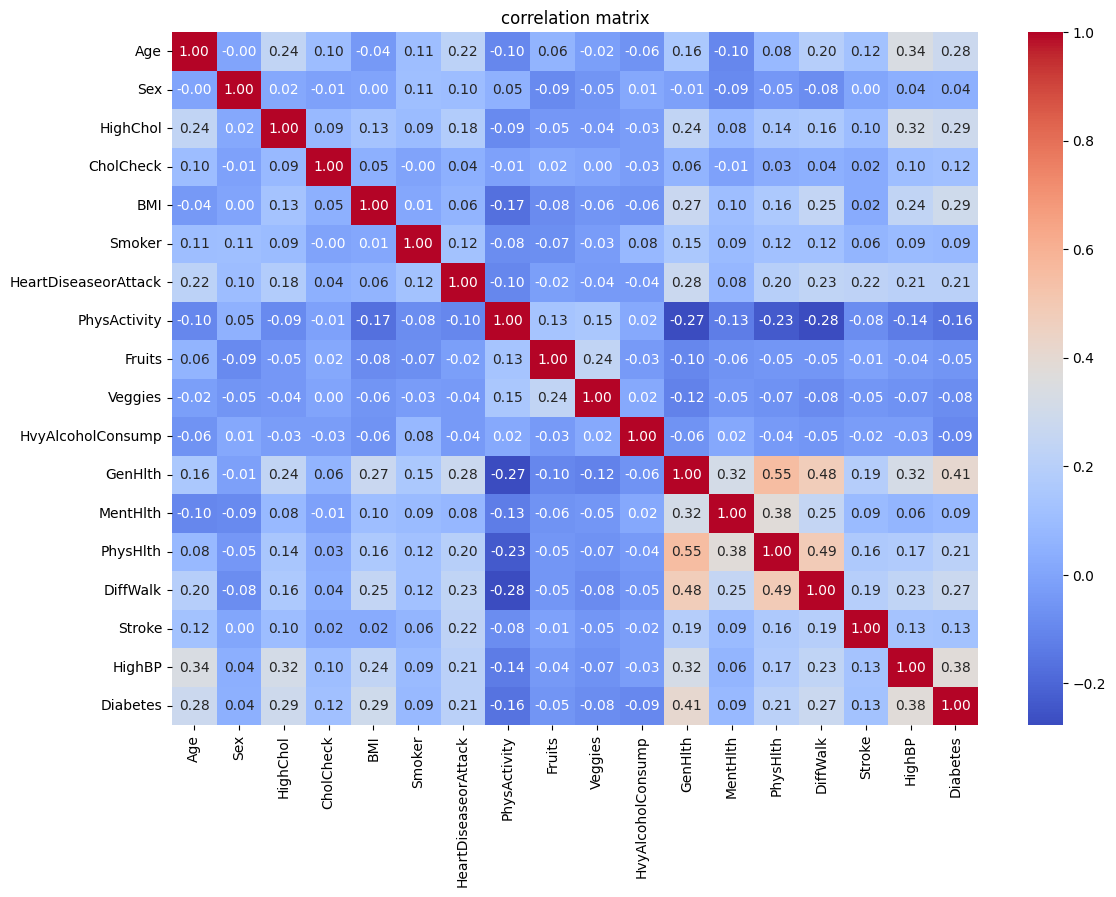

In [ ]:
# Correlation studies

plt.figure(figsize = (13,9))
sns.heatmap(diabetes.corr(), annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('correlation matrix')
plt.show()

<Axes: >

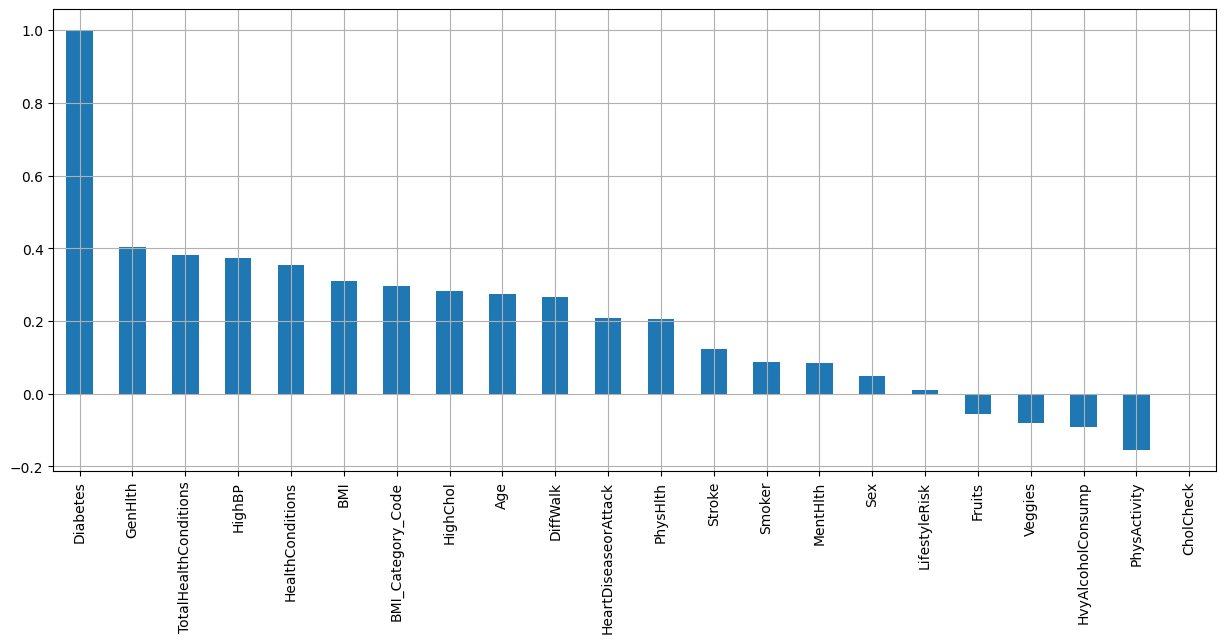

In [ ]:
#Feature correlation with target variable

diabetes.corr()['Diabetes'].sort_values(ascending=False).plot(kind = 'bar', grid = True, figsize = (15, 6))

# **HYPOTHESIS TESTING**

In [ ]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 68160 entries, 0 to 70691
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    68160 non-null  int64  
 1   Sex                    68160 non-null  int64  
 2   HighChol               68160 non-null  int64  
 3   CholCheck              68160 non-null  int64  
 4   BMI                    68160 non-null  float64
 5   Smoker                 68160 non-null  int64  
 6   HeartDiseaseorAttack   68160 non-null  int64  
 7   PhysActivity           68160 non-null  int64  
 8   Fruits                 68160 non-null  int64  
 9   Veggies                68160 non-null  int64  
 10  HvyAlcoholConsump      68160 non-null  int64  
 11  GenHlth                68160 non-null  int64  
 12  MentHlth               68160 non-null  int64  
 13  PhysHlth               68160 non-null  int64  
 14  DiffWalk               68160 non-null  int64  
 15  St

In [ ]:
diabetes = diabetes.drop(columns=['BMI_Category'])

In [ ]:
import scipy.stats as stats

# variables excluding 'Diabetes'
variables_to_test = diabetes.columns[diabetes.columns != 'Diabetes']

# Empty DataFrame to store the results
test_results = pd.DataFrame(columns=['Variable', 'Test_Statistic', 'P_Value'])

# Loop through each variable and perform the t-test
for variable in variables_to_test:
    group_0 = diabetes[diabetes['Diabetes'] == 0][variable]
    group_1 = diabetes[diabetes['Diabetes'] == 1][variable]

    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

    # Append results to the DataFrame
    test_results = test_results.append({
        'Variable': variable,
        'Test_Statistic': t_stat,
        'P_Value': p_value
    }, ignore_index=True)

# Display the results
print(test_results)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


                 Variable  Test_Statistic        P_Value
0                     Age      -74.426913   0.000000e+00
1                     Sex      -12.609922   2.044839e-36
2                HighChol      -77.003087   0.000000e+00
3               CholCheck             NaN            NaN
4                     BMI      -85.669587   0.000000e+00
5                  Smoker      -23.110305  1.037094e-117
6    HeartDiseaseorAttack      -55.835764   0.000000e+00
7            PhysActivity       41.109077   0.000000e+00
8                  Fruits       14.523458   1.014339e-47
9                 Veggies       20.891620   1.290926e-96
10      HvyAlcoholConsump       24.171791  1.967098e-128
11                GenHlth     -114.892196   0.000000e+00
12               MentHlth      -22.457926  2.811419e-111
13               PhysHlth      -55.262862   0.000000e+00
14               DiffWalk      -72.180116   0.000000e+00
15                 Stroke      -32.871335  8.704431e-235
16                 HighBP     -

# **FEATURE IMPORTANCE**

Text(0, 0.5, 'Features')

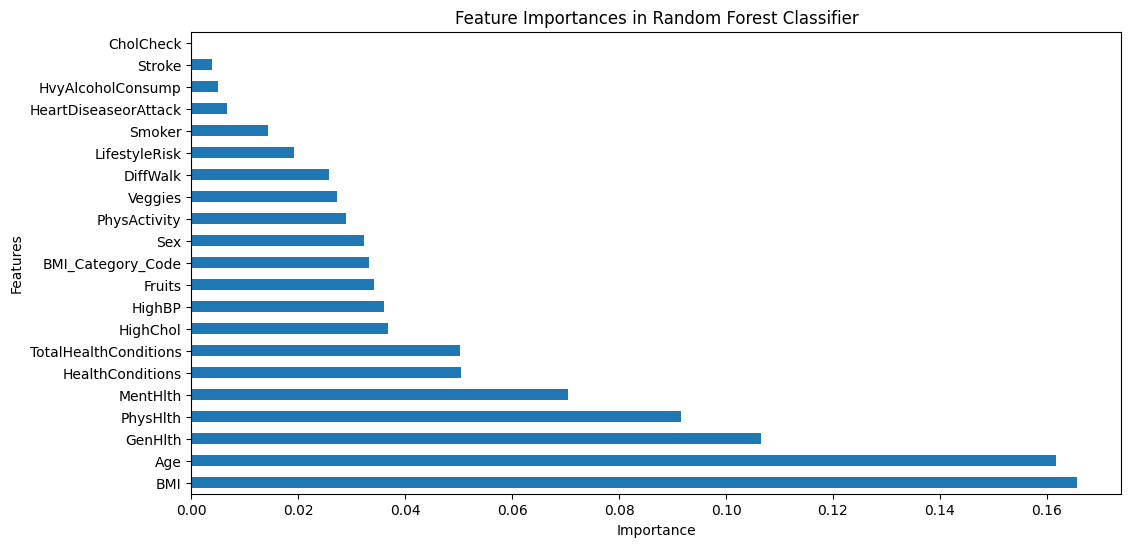

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#ExtractIng features and target variable
X = diabetes.drop('Diabetes', axis=1)
y = diabetes['Diabetes']

#Initialize a RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

#Fit the model
rf_classifier.fit(X, y)

feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='barh', figsize=(12, 6))

plt.title('Feature Importances in Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Features')


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

k = 20
chi2_selector = SelectKBest(chi2, k=k)
X_chi2 = chi2_selector.fit_transform(X, y)

#Getting chi-squared test statistics and p-values
chi2_stats = chi2_selector.scores_
p_values = chi2_selector.pvalues_

#DataFrame displaying chi-squared statistics and p-values for each feature
chi2_df = pd.DataFrame({'Feature': X.columns, 'Chi2_Stat': chi2_stats, 'P_Value': p_values})

# Sorting features by chi-squared statistics in descending order and p-values in ascending order
chi2_df = chi2_df.sort_values(by=['Chi2_Stat', 'P_Value'], ascending=[False, True])

# Chi-squared Test for Feature Selection
print(chi2_df['Feature'])

13                 PhysHlth
20         HealthConditions
12                 MentHlth
4                       BMI
19    TotalHealthConditions
0                       Age
11                  GenHlth
16                   HighBP
14                 DiffWalk
2                  HighChol
6      HeartDiseaseorAttack
17        BMI_Category_Code
15                   Stroke
10        HvyAlcoholConsump
7              PhysActivity
5                    Smoker
9                   Veggies
1                       Sex
8                    Fruits
18            LifestyleRisk
3                 CholCheck
Name: Feature, dtype: object


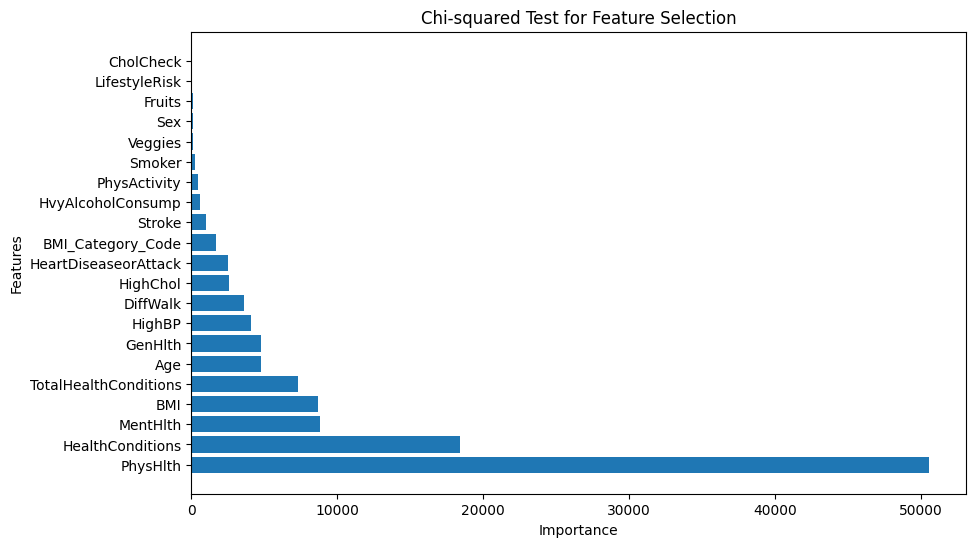

In [ ]:
#Setting up the figure
plt.figure(figsize=(10, 6))

# Plotting the features
plt.barh(chi2_df['Feature'], chi2_df['Chi2_Stat'])

#Labels and Title
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Chi-squared Test for Feature Selection')

# Show the plot
plt.show()